In [1]:
import pandas as pd

# Load dataset
df = pd.read_excel("Indus Action Technical Project Manager Pre Work.xlsx")

# Show first 5 rows
df.head()

,User ID,Timestamp,Action,Product Category,Revenue
0,abe25903-30ab-4a26-a569-604f87656d15,28-12-2024 03:26,viewed_product,Clothing,0.00
1,6475c03d-4202-470f-8ded-6f710deaff7a,2024-07-11 13:35:00,purchased,Clothing,392.36
2,fcca2524-5817-44a1-8697-2a9a8ff04c76,2024-04-12 00:33:00,added_to_cart,Sports,0.00
3,714905a0-06a3-484f-a72b-bc0787975d83,2025-12-01 12:25:00,purchased,Books,330.52
4,7dc8ec16-b498-4f9c-b768-e4725b9e6b73,25-11-2024 16:44,added_to_cart,Books,NaN


In [2]:
# Dataset structure
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User ID           251 non-null    object 
 1   Timestamp         248 non-null    object 
 2   Action            248 non-null    object 
 3   Product Category  249 non-null    object 
 4   Revenue           249 non-null    float64
dtypes: float64(1), object(4)
memory usage: 9.9+ KB


User ID             0
Timestamp           3
Action              3
Product Category    2
Revenue             2
dtype: int64

In [3]:
# Fix missing values

# Fill missing Revenue with 0
df["Revenue"] = df["Revenue"].fillna(0)

# Fill missing categorical values
df["Action"] = df["Action"].fillna("Unknown")
df["Product Category"] = df["Product Category"].fillna("Unknown")

# Drop rows where Timestamp is missing
df = df.dropna(subset=["Timestamp"])

# Convert Timestamp to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Create Date column
df["Date"] = df["Timestamp"].dt.date

# Check again
df.isnull().sum()

/var/folders/bg/6pq1w6bd48d1kh8xqxx_yg340000gn/T/ipykernel_95033/1601272849.py:14: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Timestamp"] = pd.to_datetime(df["Timestamp"])


User ID             0
Timestamp           0
Action              0
Product Category    0
Revenue             0
Date                0
dtype: int64

In [4]:
popular_categories = df["Product Category"].value_counts()

popular_categories

Product Category
Electronics       46
Sports            43
Books             43
Home & Kitchen    39
Clothing          38
Beauty            37
Unknown            2
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


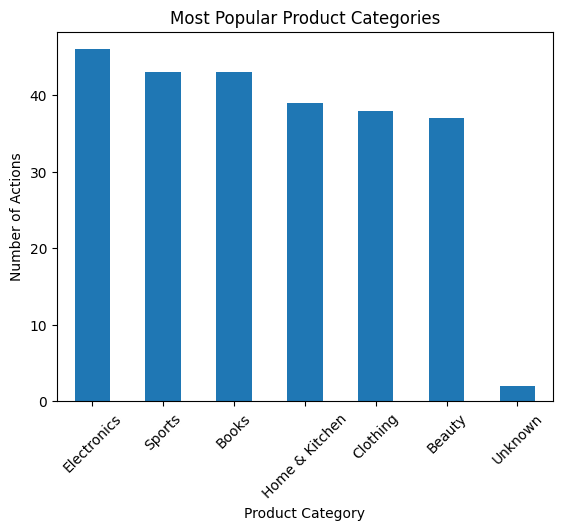

In [5]:
import matplotlib.pyplot as plt

popular_categories.plot(kind="bar")

plt.title("Most Popular Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Number of Actions")

plt.xticks(rotation=45)

plt.show()

In [6]:
popular_categories

Product Category
Electronics       46
Sports            43
Books             43
Home & Kitchen    39
Clothing          38
Beauty            37
Unknown            2
Name: count, dtype: int64

In [7]:
total_actions = len(df)

purchases = len(df[df["Action"] == "purchased"])

conversion_rate = (purchases / total_actions) * 100

print(f"Conversion Rate: {conversion_rate:.2f}%")

Conversion Rate: 28.23%


In [8]:
df["Action"].value_counts()

Action
viewed_product    88
added_to_cart     87
purchased         70
Unknown            3
Name: count, dtype: int64

In [9]:
daily_activity = df.groupby("Date").size()
daily_activity

Date
2024-01-11    3
2024-01-12    3
2024-02-11    4
2024-02-12    3
2024-03-11    1
             ..
2025-08-01    2
2025-09-01    1
2025-10-01    1
2025-11-01    1
2025-12-01    4
Length: 87, dtype: int64

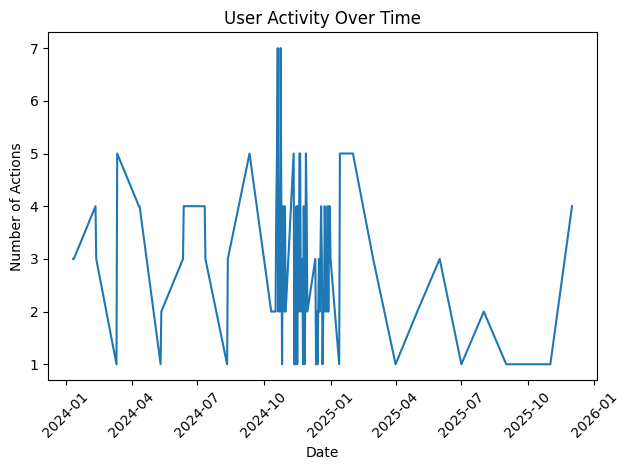

In [10]:
daily_activity.plot()

plt.title("User Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Actions")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [11]:
revenue_by_category = df.groupby("Product Category")["Revenue"].sum()
revenue_by_category

Product Category
Beauty            2120.91
Books             4916.76
Clothing          4419.71
Electronics       3172.39
Home & Kitchen    1967.76
Sports            3139.59
Unknown            220.36
Name: Revenue, dtype: float64

<Axes: xlabel='Product Category'>

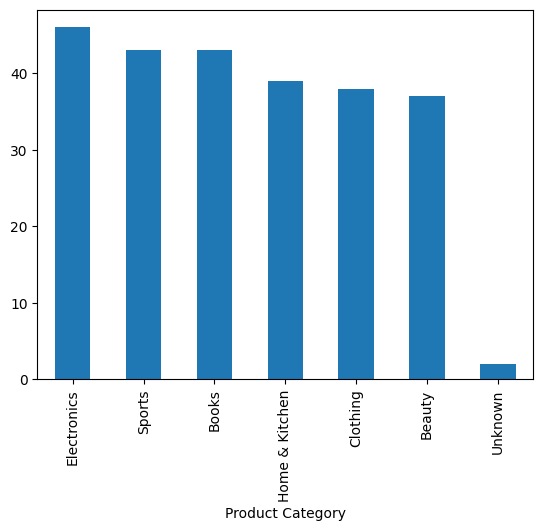

In [12]:
popular_categories.plot(kind="bar")

In [13]:
total_actions = len(df)

purchases = len(df[df["Action"] == "purchased"])

conversion_rate = (purchases / total_actions) * 100

print(conversion_rate)

28.225806451612907


In [14]:
daily_activity = df.groupby("Date").size()

<Axes: xlabel='Date'>

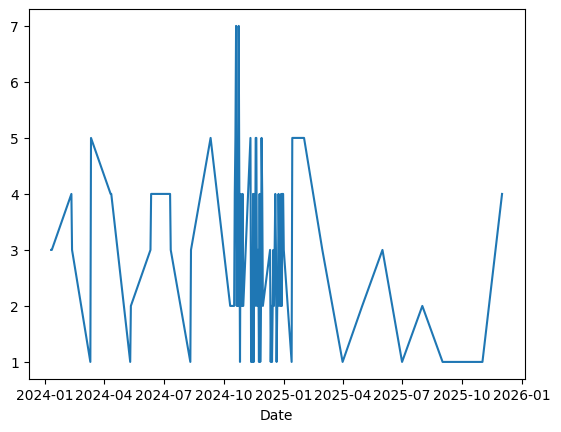

In [15]:
daily_activity.plot()

In [17]:
revenue_by_category = df.groupby("Product Category")["Revenue"].sum()

# Insights and Recommendations

## Key Insights

### 1. Most Popular Product Categories

The Electronics category recorded the highest number of user interactions with 46 actions, followed closely by Sports and Books with 43 interactions each.

Business Meaning:
High interaction levels in Electronics indicate strong user interest and demand. These categories represent key engagement drivers and should be prioritized for visibility and promotional strategies.

---

### 2. Conversion Rate Analysis

The overall conversion rate was calculated at **28.23%**, indicating that approximately one out of every four user actions resulted in a successful purchase.

Business Meaning:
A conversion rate of 28.23% reflects an efficient purchasing process and suggests that users are generally able to complete purchases successfully. However, there may still be opportunities to further improve conversion by simplifying checkout processes and offering targeted promotions.

---

### 3. User Engagement Distribution

User interaction levels across categories show relatively balanced engagement across multiple product categories such as Sports, Books, and Clothing.

Business Meaning:
Balanced engagement indicates diversified customer interests. This reduces dependency on a single category and supports stable platform performance across product segments.

---

### 4. Revenue Distribution by Category

Revenue analysis shows that the **Books category generated the highest total revenue (4916.76)**, followed by Clothing and Electronics. Despite Electronics being the most interacted category, Books generated the most revenue.

Business Meaning:
This suggests that although Electronics receives the highest engagement, customers spend more per transaction in the Books category. This highlights the importance of analyzing both interaction volume and revenue contribution.

---

## Recommendations

Based on the analysis, the following strategic recommendations are suggested:

### 1. Increase Promotion for High-Engagement Categories
Focus marketing campaigns on Electronics and Sports categories to leverage strong customer interest and increase conversions.

### 2. Prioritize High-Revenue Categories
Expand inventory and promotional efforts in the Books category, as it generates the highest revenue and shows strong sales potential.

### 3. Optimize Underperforming Categories
Categories such as Home & Kitchen and Beauty generated comparatively lower revenue. Consider offering discounts, bundles, or promotional campaigns to improve performance.

### 4. Improve Checkout Experience
Although conversion rates are relatively strong, further optimizing the checkout process may increase conversion rates beyond the current 28.23%.

### 5. Use Data-Driven Campaign Scheduling
Analyze peak activity periods and schedule marketing campaigns during high engagement times to maximize user interaction and sales outcomes.